This script aims to investigate if there is a difference in a prediction of a long and a short input sequence. Predictions with the tools was made on three input sequences. All thre sequences are Caplaziumab, but frist inputed as a singular, then the sequence was copied and made into a twice sequence (same sequence repeated twice) and one with 3 copies. 

In [ ]:
# load libaries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches

In [2]:
# load data
netMHC1_defaultSettings = pd.read_csv('tool_outputs/netMHC1_EL_defaultSettings.csv')
netMHC_II_defaultSettings = pd.read_csv('tool_outputs/netMHC_II_EL_defaultSettings.csv')
seqTable = pd.read_csv('tool_outputs/seqTable_netMHC1_EL_defaultSettings.csv')

In [3]:
# map the sequence names
netMHC1_defaultSettings = netMHC1_defaultSettings.merge(seqTable[['seq #', 'sequence name']], how='left')
netMHC_II_defaultSettings = netMHC_II_defaultSettings.merge(seqTable[['seq #', 'sequence name']], how='left')

In [4]:
# netMHC1_EL_pep9 percentile score

# Immunogenentic is defened as scored <= 1%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 1. 
netMHC1_pep9_percentile = (
    netMHC1_defaultSettings.assign(immunogenic=netMHC1_defaultSettings['netmhcpan_el percentile'] <= 1) # flags rows where percentile is below 1
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC1_pep9_percentile')
    )

# netMHC1_EL_pep9 Immunogenicity score 

# Immunogenentic is defened as scored larger than 0
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a immunogenicity score above 0. 
netMHC1_pep9_immunogenicity_score = (
    netMHC1_defaultSettings.assign(immunogenic=netMHC1_defaultSettings['immunogenicity score'] > 0) # flags rows where percentile is above 0
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC1_pep9_immunogenicity_score')
    )

# netMHC1_EL_pep9 Preprocessing score

# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
netMCH1_pep9_preProcess = netMHC1_defaultSettings.groupby('sequence name')['processing total score'].mean().reset_index().rename(columns={'processing total score': 'netMHC1_pep9_preProcess'})



# netMHC_II_EL_pep15

# Percentile score

# Immunogenentic is defened as scored <= 10%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 10. 
netMHC_II_pep15_percentile = (
    netMHC_II_defaultSettings.assign(immunogenic=netMHC_II_defaultSettings['netmhciipan_el percentile'] <= 10) # flags rows where percentile is below 10
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC_II_pep15_percentile')
    )

# Immunogenicity score

# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
netMHC_II_pep15_immunogenicity_score = netMHC_II_defaultSettings.groupby('sequence name')['immunogenicity score'].mean().reset_index().rename(columns={'immunogenicity score':'netMHC_II_pep15_immunogenicity_score'})

# Pre-proocessing score
# MHC class 2 has 2 preprocessing scores of interest: mhcii-np cleavage probability score and mhcii-np cleavage probability percentile rank

# mhcii-np cleavage probability

# remove the rows with the cleavage probability score of '-' before calculating the mean
netMHC_II_EL_pep15 = netMHC_II_defaultSettings[netMHC_II_defaultSettings['mhcii-np cleavage probability score'] != '-']
# make the column with the cleavage probability score into a numeric column
netMHC_II_EL_pep15['mhcii-np cleavage probability score'] = pd.to_numeric(netMHC_II_EL_pep15['mhcii-np cleavage probability score'])
# Compute score
# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
netMHC_II_pep15_preProcess_cleavProb = netMHC_II_EL_pep15.groupby('sequence name')['mhcii-np cleavage probability score'].mean().reset_index().rename(columns={'mhcii-np cleavage probability score': 'netMHC_II_pep15_preProcess_cleavProb'})

# mhcii-np cleavage probability percentile rank

# remove the rows with the cleavage probability percentile rank of '-' before calculating the mean
netMHC_II_EL_pep15 = netMHC_II_EL_pep15[netMHC_II_EL_pep15['mhcii-np cleavage probability percentile rank'] != '-']
# make the column with the cleavage probability percentile rank into a numeric column
netMHC_II_EL_pep15['mhcii-np cleavage probability percentile rank'] = pd.to_numeric(netMHC_II_EL_pep15['mhcii-np cleavage probability percentile rank'])
# compute score
# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
netMHC_II_pep15_preProcess_cleavProbPercentile = netMHC_II_EL_pep15.groupby('sequence name')['mhcii-np cleavage probability percentile rank'].mean().reset_index().rename(columns={'mhcii-np cleavage probability percentile rank': 'netMHC_II_pep15_preProcess_cleavProbPercentile'})



C:\Users\rebbe\AppData\Local\Temp\ipykernel_2248\2338256085.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netMHC_II_EL_pep15['mhcii-np cleavage probability score'] = pd.to_numeric(netMHC_II_EL_pep15['mhcii-np cleavage probability score'])


In [ ]:
# waltz
# rename the column '...' to nr_aggs
waltz = waltz.rename(columns={'...': 'nr_aggs'})

# compute the total number of amio acids that are considerd immunogenetic
def sum_ranges(s):
    if pd.isna(s):
        return 0
    total = 0
    for part in s.split(';'):
        start, end = part.strip().split('-')
        total += int(end) - int(start) + 1 # beacuse the values are inclusive
    return total

waltz['nr_aggs'] = waltz['waltz_score'].apply(sum_ranges)

# biophi 
# only rename the antibody column so it matches the rest
biophi_relaxed = biophi_relaxed.rename(columns={'Antibody': 'antibody'})
biophi_strict = biophi_strict.rename(columns={'Antibody': 'antibody'})

In [5]:
# Merge scores
all_predictors = netMHC1_pep9_percentile.merge(netMHC1_pep9_immunogenicity_score, on='sequence name', how='left')
all_predictors = all_predictors.merge(netMCH1_pep9_preProcess, on='sequence name', how='left')
all_predictors = all_predictors.merge(netMHC_II_pep15_percentile, on='sequence name', how='left')
all_predictors = all_predictors.merge(netMHC_II_pep15_immunogenicity_score, on='sequence name', how='left')
all_predictors = all_predictors.merge(netMHC_II_pep15_preProcess_cleavProb, on='sequence name', how='left')
all_predictors = all_predictors.merge(netMHC_II_pep15_preProcess_cleavProbPercentile, on='sequence name', how='left')

In [6]:
all_predictors

,sequence name,netMHC1_pep9_percentile,netMHC1_pep9_immunogenicity_score,netMHC1_pep9_preProcess,netMHC_II_pep15_percentile,netMHC_II_pep15_immunogenicity_score,netMHC_II_pep15_preProcess_cleavProb,netMHC_II_pep15_preProcess_cleavProbPercentile
0,Caplacizumab,3.549383,53.333333,-3.381630,10.466989,94.663083,0.121135,32.588182
1,Caplacizumabx2,3.554361,52.016129,-3.387501,10.204082,94.622988,0.141754,27.908958
2,Caplacizumabx3,3.555950,51.595745,-3.389375,10.560561,94.774984,0.165936,25.013836


In [ ]:
all_predictors.head()

,sequence name,netMHC1_pep9_percentile,netMHC1_pep9_immunogenicity_score,netMHC1_pep9_preProcess,netMHC_II_pep15_percentile,netMHC_II_pep15_immunogenicity_score,netMHC_II_pep15_preProcess_cleavProb,netMHC_II_pep15_preProcess_cleavProbPercentile
0,Caplacizumab,-1.375675,1.375675,1.375675,0.374042,-0.372137,-1.191015,1.308858
1,Caplacizumabx2,0.403868,-0.403868,-0.403868,-1.368152,-0.995513,-0.064880,-0.190568
2,Caplacizumabx3,0.971807,-0.971807,-0.971807,0.994110,1.367650,1.255895,-1.118291


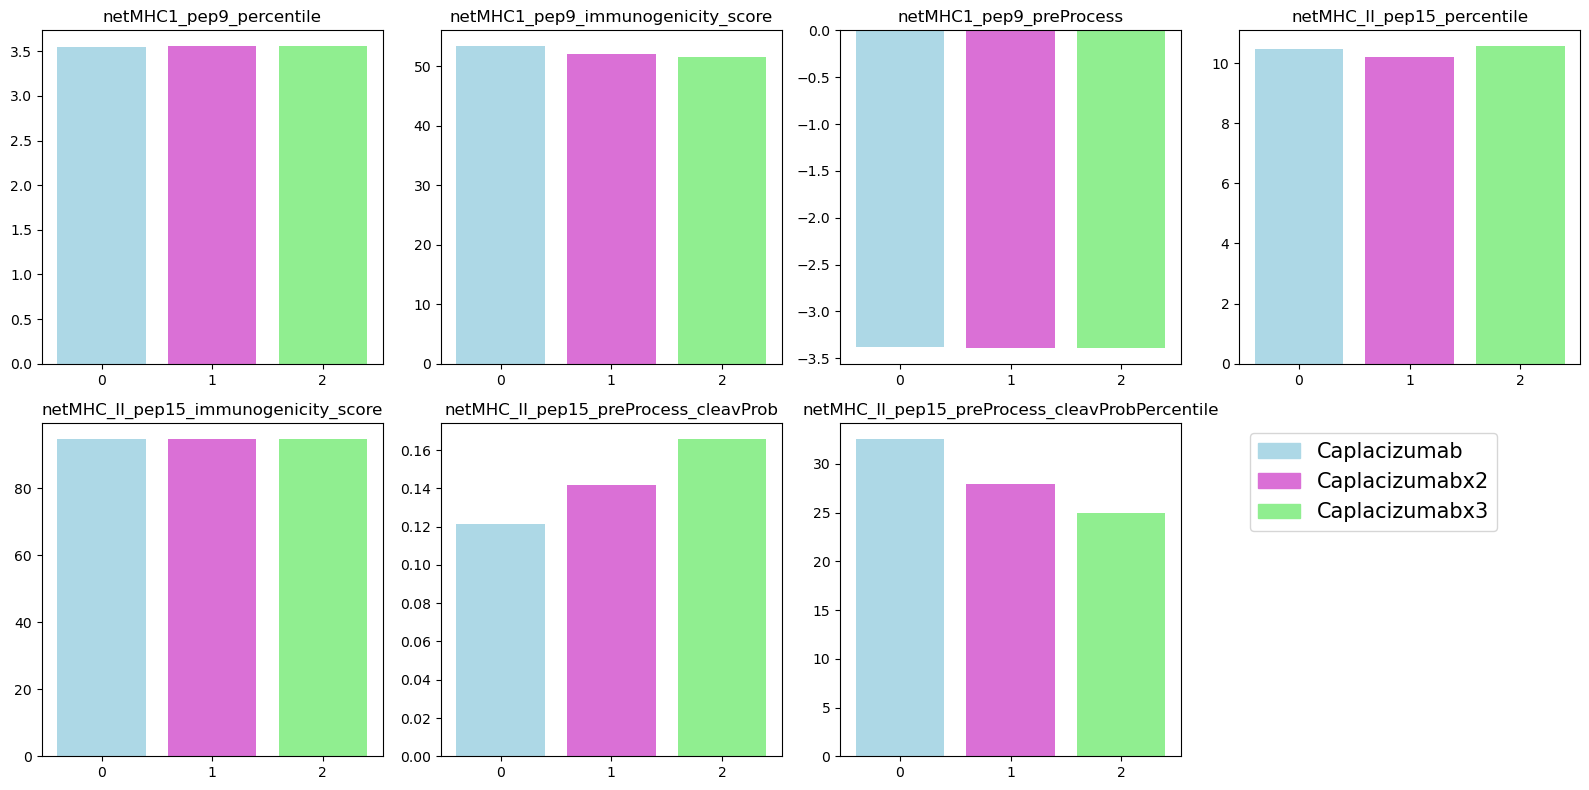

In [24]:


fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

colors = ['lightblue', 'orchid', 'lightgreen']  # one per row

for i, col in enumerate(all_predictors.columns[1:]): # skip the first column with the sequence names
    ax = axes[i]
    
    values = all_predictors[col].values # 3 values (rows)
    x = np.arange(len(values)) # [0, 1, 2]
    
    ax.bar(x, values, color=colors)
    ax.set_title(col)
    ax.set_xticks(x)
    ax.set_xticklabels(all_predictors.index)      # row names (optional)
    
# Use last subplot for legend
legend_ax = axes[-1]
legend_ax.axis('off')  # remove axes

# create legend handles
handles = [
    mpatches.Patch(
        color=colors[i],
        label=all_predictors['sequence name'].iloc[i]
    )
    for i in range(len(all_predictors))
]

# add legend to the last subplot
legend_ax.legend(handles=handles, loc='upper left', fontsize=15)

plt.tight_layout()
plt.show()

Short tool score explanation:\
**netMHC percentile**, this score is the percentage of HLA-peptide interactions that have an immunogenetic percentile score. Immunogenetic score is scores below 1. The percentile score is a comparison of the peptide IC50 score to a set of random peptides from Uniprot/Swiss-prot.\
**netMHC immunogenicity score**, this score is the percentage of HLA-peptide interactions that have an immunogenetic immunogenicity score. Immunogenetic immunogenicity score is scores above 0.
**netMHC II percentile**, same as for netMHC. But immunogenetic scores are scores below 10.\
**netMHC immunogenicity score**, this score is the mean of the HLA-peptide interaction for each antibody. Low value means more immunogenetic.\
**netMHC II cleavage probability score**, this is the mean of the HLA-peptide interaction for each antibody. Higher number means better chance of the peptide being a ligand.\
**netMHC II cleavage probability percentile score**, this is the mean of the HLA-peptide interaction for each antibody. Lower number means better chance of the peptide being a ligand.
